# 1. Import the library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

print('Loaded necessary libraries')

Loaded necessary libraries


In [2]:
# 1.1 setup visualization
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("All the settings are predefined ! ")

All the settings are predefined ! 


In [3]:
# 1.2 Load Data
base_dir = Path.cwd().parent
data_path_train = base_dir / "data" / "raw" / "credit_train.csv"
data_path_test = base_dir / "data" / "raw" / "credit_test.csv"
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)
print(f"Training set: {train_data.shape[0]: ,} rows x {train_data.shape[1]} columns")
print(f"Test set: {test_data.shape[0]: ,} rows x {test_data.shape[1]} columns")

Training set:  1,296,675 rows x 23 columns
Test set:  555,719 rows x 23 columns


## 2. Data Inspection and Statics

### 2.1 Data Inspection and Statics

In [4]:
test_df = test_data.copy()
train_df = train_data.copy()
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
train_df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


### 2.2 Data type validation

In [7]:
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
train_df['dob'] = pd.to_datetime(train_df['dob'])

test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])
test_df['dob'] = pd.to_datetime(test_df['dob'])

train_df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
# Target value
fraud_counts = train_df['is_fraud'].value_counts()
print(fraud_counts)
fraud_rate = train_df['is_fraud'].mean()
print(f"Alert: Detected fraud rate is fraud_rate:{fraud_rate: .2%}")

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Alert: Detected fraud rate is fraud_rate: 0.58%


In [9]:
train_df = train_df.set_index(train_df['Unnamed: 0'])
train_df = train_df.drop(['Unnamed: 0'], axis = 1)

test_df = test_df.set_index(test_df['Unnamed: 0'])
test_df = test_df.drop(['Unnamed: 0'], axis = 1)
train_df.head(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 3. Explore Data Analysis

### 3.1 Class Distribution

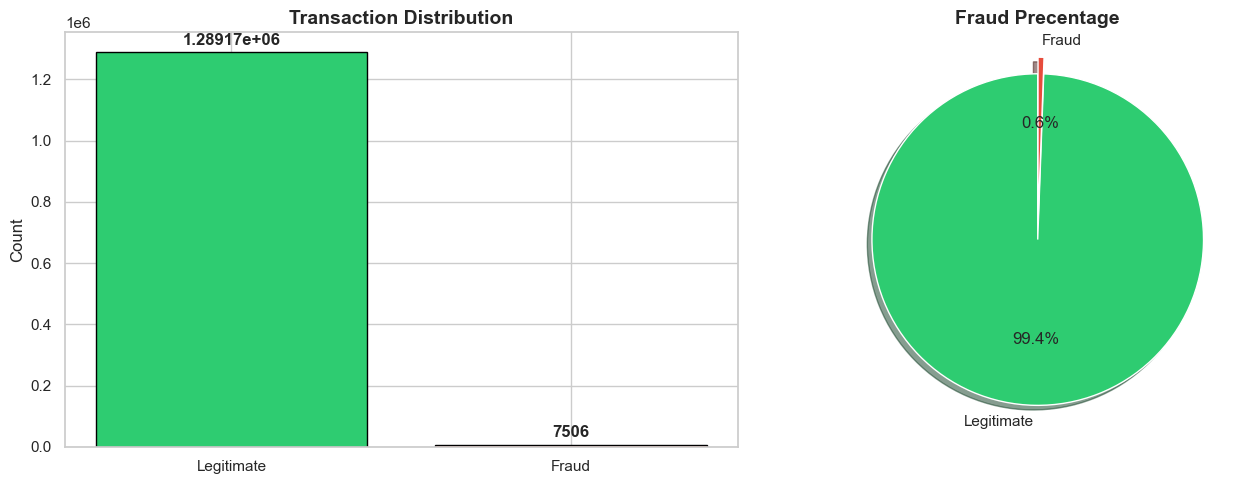

Fraud rate: 0.58%


In [10]:
# 1. Prepare Data
labels = ['Legitimate', 'Fraud'] # List format for plotting
colors = ['#2ecc71', '#e74c3c']

# 2. Create the layout(1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# -- Left plot: Bar Chart --
bar = axes[0].bar(labels, fraud_counts, color = colors, edgecolor = 'black')
axes[0].set_title('Transaction Distribution', fontweight = 'bold', fontsize = 14)
axes[0].bar_label(bar, padding=3, fontweight='bold')
axes[0].set_ylabel('Count')

# -- Right plot: Pie Chart
axes[1].pie(fraud_counts, labels = labels, autopct = '%1.1f%%', colors = colors, startangle = 90, explode = (0, 0.1), shadow = True)
axes[1].set_title("Fraud Precentage", fontweight = 'bold', fontsize = 14)

plt.tight_layout()
plt.show()

print(f"Fraud rate: {fraud_rate:.2%}")

For this data, you should ignore "Accuracy" and instead focus on Precision-Recall or the F1-Score to ensure the model is actually identifying the 7,506 fraud cases. Additionally, we can use ROC-AUC and PR-AUC for evaluation.

Recommend:
To train a good model, you will likely neead to use techniques SMOTE(oversampling the fraud) or Under-sampling (reducing the legitimate count) so the model can learn the patterns of fraud more effectively.

### 3.2 Transection Amount Risk

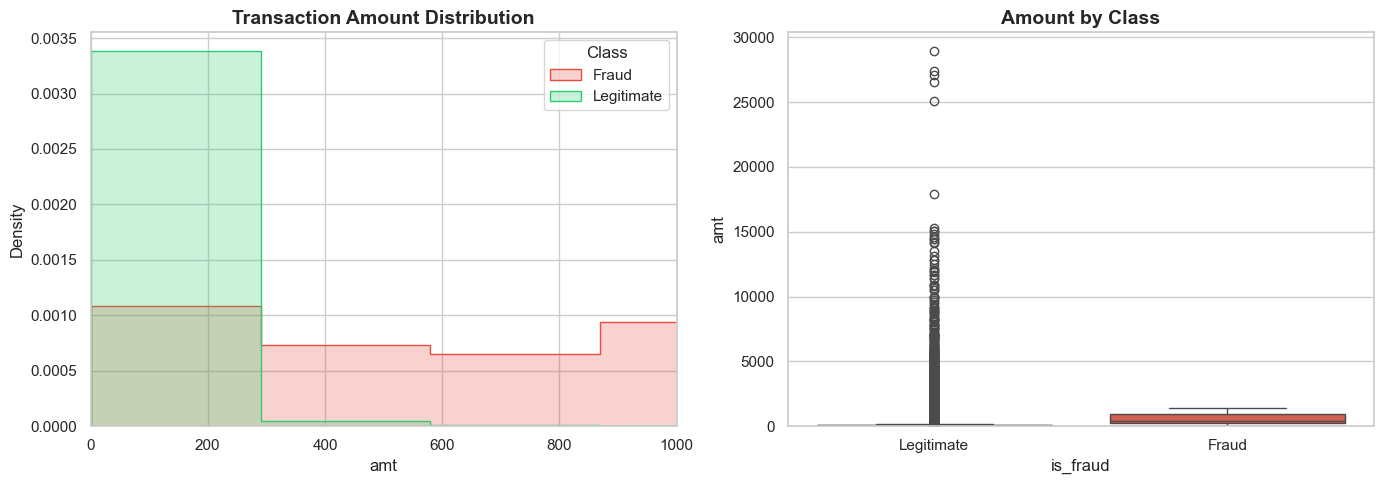

--- Amount Statistics ---


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.67,154.01,1.00,9.61,47.28,82.54,28948.90
1,7506.0,531.32,390.56,1.06,245.66,396.50,900.88,1376.04


In [11]:
fig, axes = plt.subplots(1, 2, figsize = (14,5))
colors = ['#2ecc71', '#e74c3c']
# 1. Distribution plot: Seaborn handles the 'subsetting' and 'legend' for you
sns.histplot(data = train_df, x = 'amt', hue = 'is_fraud', bins = 100, palette = colors, element= 'step', fill= True, stat= 'density', common_norm= False, ax = axes[0])
axes[0].set_ylim(0, None)
axes[0].set_xlim(0, 1000)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold', fontsize = 14)
axes[0].legend(title='Class', labels=['Fraud', 'Legitimate'])

#2. Box plot
sns.boxplot(data = train_df, x = 'is_fraud', y = 'amt', palette= colors, ax = axes[1])
axes[1].set_title('Amount by Class', fontweight = 'bold', fontsize = 14)
axes[1].set_ylim(0, None)
axes[1].set_xticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

# Stats Summary
print("--- Amount Statistics ---")
display(train_df.groupby('is_fraud')['amt'].describe().round(2))

- Based on the histplot, legitimate transactions have a significantly higher density than fraudulent ones, concentrated in the $0–$300 range, while fraudulent transactions can extend above $1,000.
- The mean fraudulent transaction amount ($531.32) is approximately 8x higher than legitimate transactions ($67.67).
- Fraudulent transactions range from $1.06 to $1,376, while legitimate transactions have a much wider range of $1 to $28,948. This suggests fraudsters avoid extremely large amounts to evade detection systems.

Conclusion: The amt feature provides good class separability between fraudulent and legitimate transactions, making it a valuable feature for fraud detection


### 3.3 Category Risk

In [24]:
# 1. Aggration (Double check the rate is multiplied)
cat_fraud = train_df.groupby('category')['is_fraud'].agg(total = 'count', fraud_rate = lambda x: x.mean() * 100).sort_values('fraud_rate')
cat_fraud

,total,fraud_rate
category,,
health_fitness,85879,0.154869
home,123115,0.160825
food_dining,91461,0.165098
kids_pets,113035,0.211439
personal_care,90758,0.242403
entertainment,94014,0.247835
travel,40507,0.286370
grocery_net,45452,0.294817
misc_pos,79655,0.313853


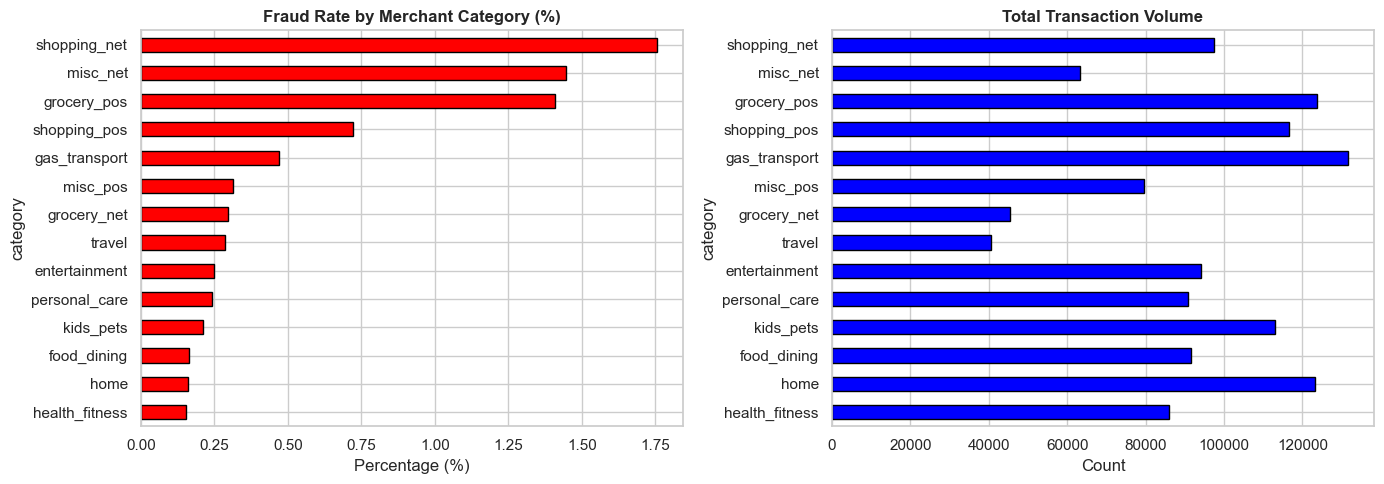

In [38]:
# 2. Create Plot
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# Chart 1: Rate
cat_fraud['fraud_rate'].plot(kind = 'barh',ax = axes[0], color = 'red', edgecolor = 'black')
axes[0].set_title('Fraud Rate by Merchant Category (%)', fontweight='bold')
axes[0].set_xlabel('Percentage (%)')

# Chart 2: Volume
cat_fraud['total'].plot(kind = 'barh',ax = axes[1], color = 'blue', edgecolor = 'black')
axes[1].set_title('Total Transaction Volume', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

- While online categories (shopping_net, misc_net) show the highest fraud rates (~1.5–1.75%), their transaction volumes are relatively low.
- High-volume categories like gas_transport have moderate fraud rates (~0.45%) but may contribute more fraud cases in absolute terms. Although category shows some signal — particularly online vs. offline channels — the differences are not large enough to be a strong standalone predictor of fraud.

In [39]:
train_df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')